<a href="https://colab.research.google.com/github/ifrah123781/Project-2-Exploratory-Data-Analysis-EDA-/blob/main/DecodeLabs_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import glob

STEP # 1: UPLOA AND LOAD THE DATASET

In [8]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel("Dataset for Data Analytics (1).xlsx")

df.shape

Saving Dataset for Data Analytics (1).xlsx to Dataset for Data Analytics (1) (3).xlsx


(1200, 14)

STEP # 2: UNDERSTAND THE DATASET


In [9]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


STEP # 3: CHECK DATA TYPES & MISSING VALUES

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

STEP # 4: CALCULATE BASIC STATISTICS (MEAN, MEDIAN, COUNT)

In [11]:
# selecting columns
num_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

# creating tables
basic_stats = pd.DataFrame({
    'Count': df[num_cols].count(),
    'Mean': df[num_cols].mean().round(2),
    'Median': df[num_cols].median().round(2),
    'Standard Deviation': df[num_cols].std().round(2),
    'Minimum': df[num_cols].min().round(2),
    'Maximum': df[num_cols].max().round(2)
})

# output
basic_stats

,Count,Mean,Median,Standard Deviation,Minimum,Maximum
Quantity,1200,2.95,3.00,1.41,1.00,5.00
UnitPrice,1200,356.41,364.21,197.18,11.39,699.93
ItemsInCart,1200,5.48,5.00,2.28,1.00,10.00
TotalPrice,1200,1053.97,823.62,819.86,11.39,3456.40


STEP # 5: IDENTIFY OUTLIERS (IQR METHOD)

In [12]:
# Key Requirement 2 (Part A): Outlier Detection (Clean & Direct)
for col in ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']:
 q1 = df[col].quantile(0.25)
 q3 = df[col].quantile(0.75)
 iqr = q3 - q1
 lower_bound = q1 - (1.5 * iqr)
 upper_bound = q3 + (1.5 * iqr)

 outliers_count = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])
 print(f"{col} -> Outliers: {outliers_count} (Normal Range: {lower_bound: .2f} to {upper_bound: .2f})")

Quantity -> Outliers: 0 (Normal Range: -1.00 to  7.00)
UnitPrice -> Outliers: 0 (Normal Range: -317.20 to  1024.83)
ItemsInCart -> Outliers: 0 (Normal Range: -0.50 to  11.50)
TotalPrice -> Outliers: 8 (Normal Range: -1341.41 to  3330.41)


STEP # 6: VISUALIZING TRENDS & DISTRIBUTIONS

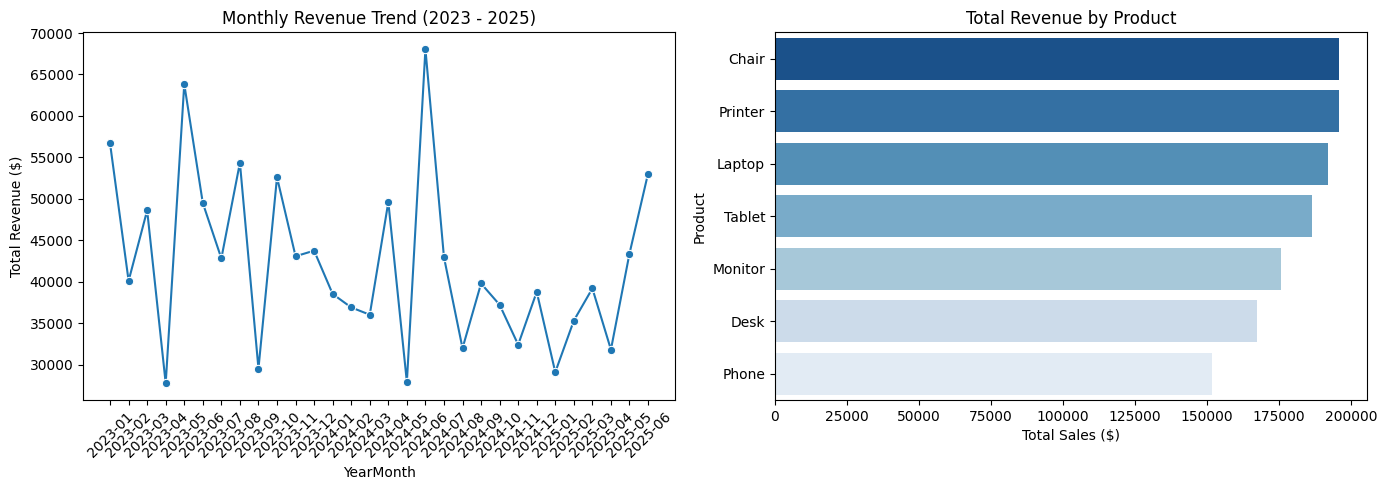

In [13]:
# Key Requirement 2 (Part B): Identify Trends & Distributions
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Date format theek karna aur Year-Month column banana
df['Date'] = pd.to_datetime(df['Date'])
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)

# 2. Monthly sales calculate karna
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()

# 3. Charts plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Line Chart (Monthly Revenue Trend)
sns.lineplot(data=monthly_sales, x='YearMonth', y='TotalPrice', marker='o', ax=axes[0], color='tab:blue')
axes[0].set_title("Monthly Revenue Trend (2023 - 2025)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Total Revenue ($)")

# Chart 2: Bar Chart (Revenue by Product - Warning fixed)
prod_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=prod_revenue, x='TotalPrice', y='Product', hue='Product', legend=False, ax=axes[1], palette='Blues_r')
axes[1].set_title("Total Revenue by Product")
axes[1].set_xlabel("Total Sales ($)")

plt.tight_layout()
plt.show()

STEP # 7: SUMMERIZE KEY OBSERVATIONS

In [14]:
# Key Requirement 3: Summarize Key Observations
summary = """
=====================================================
          PROJECT 2: EDA KEY OBSERVATIONS
=====================================================

1. Basic Statistics:
   - Total Transactions: 1,200 orders across 14 features.
   - Quantity: Mean = 2.95, Median = 3.00 (Customers mostly purchase ~3 units).
   - Unit Price: Mean = $356.41, Median = $364.21 (Evenly spread from $11.39 to $699.93).
   - Total Order Value: Mean = $1,053.97, Median = $823.62 (Right-skewed due to multi-item purchases).

2. Outlier Analysis (IQR Method):
   - Quantity, UnitPrice, and ItemsInCart contain ZERO outliers.
   - TotalPrice contains 8 statistical outliers (values > $3,330.41, max: $3,456.40).
   - Insight: These outliers are genuine high-value purchases (5 units x high unit price), not corrupted data.

3. Trends & Patterns:
   - Product Performance: Chairs ($195.6K) and Printers ($195.6K) generated the highest revenue, while Phones generated the lowest ($151.7K).
   - Order Status Alert: 41.42% of all orders are either Cancelled (250) or Returned (247), indicating a fulfillment/customer retention issue.
   - Revenue Stability: Sales remain steady around ~$40K-$50K per month throughout 2023–2025.
=====================================================
"""
print(summary)


          PROJECT 2: EDA KEY OBSERVATIONS

1. Basic Statistics:
   - Total Transactions: 1,200 orders across 14 features.
   - Quantity: Mean = 2.95, Median = 3.00 (Customers mostly purchase ~3 units).
   - Unit Price: Mean = $356.41, Median = $364.21 (Evenly spread from $11.39 to $699.93).
   - Total Order Value: Mean = $1,053.97, Median = $823.62 (Right-skewed due to multi-item purchases).

2. Outlier Analysis (IQR Method):
   - Quantity, UnitPrice, and ItemsInCart contain ZERO outliers.
   - TotalPrice contains 8 statistical outliers (values > $3,330.41, max: $3,456.40).
   - Insight: These outliers are genuine high-value purchases (5 units x high unit price), not corrupted data.

3. Trends & Patterns:
   - Product Performance: Chairs ($195.6K) and Printers ($195.6K) generated the highest revenue, while Phones generated the lowest ($151.7K).
   - Order Status Alert: 41.42% of all orders are either Cancelled (250) or Returned (247), indicating a fulfillment/customer retention issue.